# 05 Error Analysis

This notebook performs validation-only error analysis across the implemented baseline and deep-learning model families, including the current Stage 14 fusion CNN, Stage 15 TCN ensemble, and Stage 16 temporal fusion TCN ensemble artifacts when available. The held-out test split is not loaded or evaluated here.

## Setup

The reusable error-analysis helpers accept validation prediction tables and produce comparable metrics, coverage summaries, error-type counts, participant summaries, transition-neighborhood diagnostics, confidence diagnostics, model-agreement summaries, and confusion-matrix figures.

In [1]:
import sys
from pathlib import Path

import pandas as pd

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.error_analysis import (
    DEFAULT_STAGE13_OUTPUT_DIR,
    build_stage6_validation_prediction_tables,
    discover_validation_prediction_files,
    load_discovered_predictions,
    materialize_deep_validation_predictions_from_checkpoints,
    run_stage13_error_analysis,
)

data_interim_dir = repo_root / "data/interim"
data_processed_dir = repo_root / "data/processed"
results_dir = repo_root / "results"
stage13_output_dir = repo_root / DEFAULT_STAGE13_OUTPUT_DIR
stage13_prediction_dir = stage13_output_dir / "predictions"

stage13_output_dir.mkdir(parents=True, exist_ok=True)
stage13_prediction_dir.mkdir(parents=True, exist_ok=True)
stage13_output_dir

PosixPath('/home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis')

## Optional Stage 6 Prediction Tables

The original Stage 6 notebook saves validation metrics and confusion matrices, but not epoch-level predictions. Enable this guarded cell to rebuild the existing Stage 6 model types from the saved train/validation feature tables and write prediction CSVs for validation error analysis. This uses only `features_train.csv` for fitting/CV and `features_val.csv` for prediction.

In [ ]:
BUILD_STAGE6_PREDICTIONS = False

if BUILD_STAGE6_PREDICTIONS:
    stage6_predictions = build_stage6_validation_prediction_tables(
        train_features_path=data_processed_dir / "features_train.csv",
        val_features_path=data_processed_dir / "features_val.csv",
        output_dir=stage13_prediction_dir,
        include_xgboost=True,
    )
    print(f"Saved {len(stage6_predictions)} Stage 6 prediction table(s).")
else:
    print("Skipping Stage 6 prediction rebuild. Set BUILD_STAGE6_PREDICTIONS = True when feature tables are available.")

/home/manns79/dreamt-wearable-sleep-staging/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:883: UserWarning: The scoring <function _fit_cv_or_plain.<locals>.<lambda> at 0x7a1e9db807c0> does not support sample_weight, which may lead to statistically incorrect results when fitting GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_p...
                  

Saved 3 Stage 6 prediction table(s).


## Optional Deep Prediction Export

Deep-learning runs from the current training utilities write `validation_epoch_predictions.csv`, `validation_aggregated_epoch_predictions_*.csv`, or ensemble validation prediction files depending on model family. For routine error analysis, leave the export flag below as `False` and first inspect the discovery table. Only enable it if a completed validation run has a saved checkpoint but is missing its validation prediction CSV; the helper performs validation inference only and records per-run errors in the summary table instead of using the test split.

In [3]:
MATERIALIZE_DEEP_PREDICTIONS_FROM_CHECKPOINTS = False

if MATERIALIZE_DEEP_PREDICTIONS_FROM_CHECKPOINTS:
    print("Exporting missing validation predictions from saved checkpoints; no training or test evaluation is run.")
    materialization_summary = materialize_deep_validation_predictions_from_checkpoints(
        results_dir=results_dir,
        overwrite=False,
    )
    display(materialization_summary)
    if not materialization_summary.empty and "status" in materialization_summary:
        failed_exports = materialization_summary[materialization_summary["status"] == "error"]
        if not failed_exports.empty:
            print("One or more checkpoint exports failed; review the error rows before continuing.")
else:
    print("Skipping checkpoint-based deep prediction export. First inspect prediction_discovery below; set MATERIALIZE_DEEP_PREDICTIONS_FROM_CHECKPOINTS = True only for completed runs that have checkpoints but no validation prediction CSV.")

Skipping checkpoint-based deep prediction export. First inspect prediction_discovery below; set MATERIALIZE_DEEP_PREDICTIONS_FROM_CHECKPOINTS = True only for completed runs that have checkpoints but no validation prediction CSV.


## Discover Validation Predictions

This discovery step includes Stage 6 prediction tables, single-output deep prediction tables, Stage 12 aggregated many-to-many prediction tables, and current Stage 14/15/16 validation prediction artifacts when available.

In [4]:
prediction_discovery = discover_validation_prediction_files(results_dir=results_dir)
prediction_discovery

,path,stage,model_family,model_name
0,/home/manns79/dreamt-wearable-sleep-staging/re...,stage6,feature_baseline,logistic_elasticnet
1,/home/manns79/dreamt-wearable-sleep-staging/re...,stage6,feature_baseline,xgboost_all_features
2,/home/manns79/dreamt-wearable-sleep-staging/re...,stage6,sanity_baseline,majority_class
3,/home/manns79/dreamt-wearable-sleep-staging/re...,stage9,single_epoch_cnn,stage9_best_single_epoch_cnn
4,/home/manns79/dreamt-wearable-sleep-staging/re...,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru
5,/home/manns79/dreamt-wearable-sleep-staging/re...,stage10,context,stage10_best_context_cnn
6,/home/manns79/dreamt-wearable-sleep-staging/re...,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform
7,/home/manns79/dreamt-wearable-sleep-staging/re...,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted
8,/home/manns79/dreamt-wearable-sleep-staging/re...,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn
9,/home/manns79/dreamt-wearable-sleep-staging/re...,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn_sqrt_weighted


## Load Epoch Metadata

`epoch_index.csv` adds participant identity, valid validation coverage, missingness columns, and true temporal transition context. If it is unavailable, the notebook still runs the model-level analyses that only require prediction tables.

In [5]:
epoch_index_path = data_interim_dir / "epoch_index.csv"
if epoch_index_path.exists():
    epoch_index = pd.read_csv(epoch_index_path, dtype={"participant_id": str})
    print(f"Loaded epoch index with {len(epoch_index):,} row(s).")
else:
    epoch_index = pd.DataFrame()
    print(f"Epoch index not found at {epoch_index_path}; metadata-linked summaries will be skipped or empty.")

Loaded epoch index with 106,060 row(s).


## Run Validation Error Analysis

This cell writes validation error-analysis artifacts under `results/stage13_error_analysis/`. It is validation-only: it analyzes whatever validation prediction tables are available and does not load the held-out test feature table or test epochs.

In [6]:
if prediction_discovery.empty:
    print("No validation error-analysis-compatible prediction files were found yet.")
    print("Run completed model stages after this implementation, or enable the Stage 6 prediction rebuild above.")
    stage13_outputs = {}
else:
    validation_predictions = load_discovered_predictions(prediction_discovery)
    stage13_outputs = run_stage13_error_analysis(
        validation_predictions,
        epoch_index=epoch_index,
        output_dir=stage13_output_dir,
        transition_radius=2,
        high_confidence_threshold=0.80,
        make_plots=True,
    )
    print(f"Analyzed {len(validation_predictions):,} validation prediction row(s).")
    print(f"Saved validation error-analysis artifacts to {stage13_output_dir.resolve()}.")
    display(stage13_outputs["model_validation_metrics"])
    display(stage13_outputs["model_coverage"])

Analyzed 192,208 validation prediction row(s).
Saved validation error-analysis artifacts to /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis.


,stage,model_family,model_name,n_predictions,n_participants,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
9,stage16,frozen_stage14_embedding_tcn_s61,stage16_equal_weight_seed_ensemble,12027,15,0.661345,0.515297,0.506251,0.411196,0.563981,0.475620,0.784116,0.758828,0.771265,0.347969,0.223082,0.271870
10,stage16,frozen_stage14_embedding_tcn_s61,stage16_temporal_fusion_tcn_s61_center_weighted,12027,15,0.629500,0.524375,0.497487,0.384527,0.636019,0.479286,0.792694,0.692208,0.739051,0.311270,0.244898,0.274124
11,stage16,frozen_stage14_embedding_tcn_s61,stage16_temporal_fusion_tcn_s61_uniform,12027,15,0.628087,0.523750,0.496472,0.383452,0.636967,0.478718,0.792083,0.690089,0.737577,0.309821,0.244194,0.273121
6,stage15,frozen_stage14_embedding_tcn,stage15_equal_weight_seed_ensemble,12027,15,0.642139,0.495485,0.491921,0.481164,0.478199,0.479677,0.772567,0.746469,0.759294,0.216153,0.261787,0.236792
7,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_center_weighted,12027,15,0.666667,0.470509,0.484615,0.573718,0.339336,0.426444,0.751706,0.816737,0.782874,0.234496,0.255454,0.244527
8,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_uniform,12027,15,0.664422,0.470722,0.483959,0.561971,0.345972,0.428278,0.752290,0.812147,0.781073,0.232005,0.254046,0.242526
5,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn_sqrt_weighted,12027,15,0.612372,0.452451,0.445788,0.368506,0.430332,0.397027,0.766613,0.726460,0.745996,0.188492,0.200563,0.194340
4,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,12027,15,0.674815,0.415751,0.421734,0.469633,0.315166,0.377198,0.737100,0.865937,0.796341,0.149206,0.066151,0.091663
15,stage9,single_epoch_cnn,stage9_best_single_epoch_cnn,12027,15,0.472853,0.426568,0.384392,0.275794,0.329384,0.300216,0.763043,0.514713,0.614747,0.163930,0.435609,0.238214
13,stage6,feature_baseline,xgboost_all_features,12027,15,0.476594,0.429716,0.383188,0.292050,0.586730,0.389983,0.753680,0.494115,0.596900,0.133454,0.208304,0.162682


,stage,model_family,model_name,n_predictions,n_unique_epochs,n_participants,n_reference_validation_epochs,coverage_fraction,n_reference_epochs_covered
0,stage10,context,stage10_best_context_cnn,11867,11867,15,12027,0.986697,11867
1,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,11963,11963,15,12027,0.994679,11963
2,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted,12027,12027,15,12027,1.000000,12027
3,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform,12027,12027,15,12027,1.000000,12027
4,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,12027,12027,15,12027,1.000000,12027
5,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn_sqrt_weighted,12027,12027,15,12027,1.000000,12027
6,stage15,frozen_stage14_embedding_tcn,stage15_equal_weight_seed_ensemble,12027,12027,15,12027,1.000000,12027
7,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_center_weighted,12027,12027,15,12027,1.000000,12027
8,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_uniform,12027,12027,15,12027,1.000000,12027
9,stage16,frozen_stage14_embedding_tcn_s61,stage16_equal_weight_seed_ensemble,12027,12027,15,12027,1.000000,12027


## Error Patterns

Review the most common true-label to predicted-label mistakes, participant-level failures, temporal transition effects, and high-confidence errors. These outputs are intended to guide backup modeling choices such as richer features, calibration, temporal smoothing, or simple ensembling.

In [7]:
if stage13_outputs:
    display(stage13_outputs["error_type_summary"].head(20))
    display(stage13_outputs["participant_error_summary"].head(20))
    if "temporal_error_summary" in stage13_outputs:
        display(stage13_outputs["temporal_error_summary"])
    display(stage13_outputs["confidence_summary"])
    display(stage13_outputs["model_disagreement_summary"])
    display(stage13_outputs["shared_epoch_model_metrics"])
else:
    print("Run the validation error-analysis cell above after prediction tables are available.")

,stage,model_family,model_name,true_label,pred_label,error_type,count,model_error_fraction,model_prediction_fraction
1,stage10,context,stage10_best_context_cnn,Non-REM,Wake,Non-REM -> Wake,1788,0.350313,0.150670
2,stage10,context,stage10_best_context_cnn,REM,Non-REM,REM -> Non-REM,1166,0.228448,0.098256
4,stage10,context,stage10_best_context_cnn,Wake,Non-REM,Wake -> Non-REM,990,0.193966,0.083425
0,stage10,context,stage10_best_context_cnn,Non-REM,REM,Non-REM -> REM,871,0.170650,0.073397
3,stage10,context,stage10_best_context_cnn,REM,Wake,REM -> Wake,162,0.031740,0.013651
5,stage10,context,stage10_best_context_cnn,Wake,REM,Wake -> REM,127,0.024882,0.010702
6,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,Non-REM,REM,Non-REM -> REM,4721,0.553718,0.394633
7,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,Non-REM,Wake,Non-REM -> Wake,1944,0.228008,0.162501
11,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,Wake,REM,Wake -> REM,905,0.106146,0.075650
9,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,REM,Wake,REM -> Wake,374,0.043866,0.031263


,stage,model_family,model_name,participant_id,n_predictions,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,...,true_Non_REM_count,true_REM_count,mean_missingness_BVP,mean_missingness_ACC_X,mean_missingness_ACC_Y,mean_missingness_ACC_Z,mean_missingness_TEMP,mean_missingness_EDA,mean_missingness_HR,mean_missingness_IBI
11,stage10,context,stage10_best_context_cnn,S089,702,0.232194,0.267155,0.140853,0.279514,0.797030,...,451,49,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,stage10,context,stage10_best_context_cnn,S078,830,0.572289,0.327812,0.242656,0.000000,0.000000,...,483,202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,stage10,context,stage10_best_context_cnn,S032,800,0.226250,0.553686,0.253491,0.284153,0.597701,...,669,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,stage10,context,stage10_best_context_cnn,S071,711,0.645570,0.333333,0.261538,0.000000,0.000000,...,459,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,stage10,context,stage10_best_context_cnn,S047,720,0.408333,0.447337,0.284036,0.227373,0.980952,...,529,86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,stage10,context,stage10_best_context_cnn,S057,752,0.667553,0.345701,0.294968,1.000000,0.043103,...,500,136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,stage10,context,stage10_best_context_cnn,S008,738,0.601626,0.417338,0.325899,0.151515,0.490196,...,550,137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,stage10,context,stage10_best_context_cnn,S094,830,0.546988,0.403033,0.353988,0.308869,0.594118,...,574,86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,stage10,context,stage10_best_context_cnn,S092,882,0.868481,0.364198,0.366079,1.000000,0.092593,...,756,18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,stage10,context,stage10_best_context_cnn,S086,822,0.655718,0.399982,0.381200,0.416107,0.271930,...,514,80,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,stage,model_family,model_name,near_transition,transition_radius_epochs,n_predictions,mean_label_run_length,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
0,stage10,context,stage10_best_context_cnn,False,2,8481,88.290886,0.613607,0.456498,0.404105,0.308338,0.618947,0.411621,0.796371,0.698286,0.744110,0.061684,0.052261,0.056583
1,stage10,context,stage10_best_context_cnn,True,2,3386,19.129652,0.460425,0.329761,0.325382,0.330859,0.292409,0.310448,0.553095,0.640502,0.593598,0.100000,0.056373,0.072100
2,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,False,2,8531,88.000703,0.285195,0.407562,0.274477,0.205867,0.397773,0.271315,0.834980,0.219490,0.347605,0.123036,0.605422,0.204511
3,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,True,2,3432,18.991259,0.292541,0.356570,0.288175,0.346906,0.393715,0.368831,0.558519,0.195135,0.289221,0.131458,0.480861,0.206471
4,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted,False,2,8570,87.749592,0.488681,0.440014,0.367353,0.202908,0.603143,0.303660,0.823443,0.514495,0.633299,0.139406,0.202405,0.165100
5,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted,True,2,3457,18.888921,0.413075,0.364624,0.355461,0.315972,0.333333,0.324421,0.573761,0.488671,0.527809,0.176651,0.271868,0.214153
6,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform,False,2,8570,87.749592,0.486931,0.440371,0.366925,0.202498,0.605108,0.303448,0.824035,0.511596,0.631272,0.139822,0.204409,0.166056
7,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform,True,2,3457,18.888921,0.415678,0.368686,0.358845,0.320591,0.337912,0.329024,0.576806,0.489186,0.529395,0.179059,0.278960,0.218115
8,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,False,2,8570,87.749592,0.729522,0.454478,0.459004,0.491935,0.419450,0.452810,0.798226,0.878853,0.836601,0.133745,0.065130,0.087601
9,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,True,2,3457,18.888921,0.539196,0.369618,0.357034,0.434307,0.217949,0.290244,0.577577,0.822348,0.678564,0.201389,0.068558,0.102293


,stage,model_family,model_name,is_correct,n_predictions,mean_confidence,median_confidence,mean_margin,mean_entropy
0,stage10,context,stage10_best_context_cnn,False,5104,0.784473,0.828082,0.618078,4.862827e-01
1,stage10,context,stage10_best_context_cnn,True,6763,0.855496,0.943832,0.738471,3.424464e-01
2,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,False,8526,0.658070,0.685916,0.448739,8.232424e-01
3,stage11,cnn_gru_many_to_one,stage11_best_cnn_gru,True,3437,0.591660,0.566015,0.325470,8.858945e-01
4,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted,False,6411,0.600163,0.562712,0.321636,8.563132e-01
5,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_center_weighted,True,5616,0.583569,0.559148,0.284377,8.812654e-01
6,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform,False,6417,0.598709,0.562186,0.320399,8.589344e-01
7,stage12,cnn_gru_many_to_many,stage12_best_cnn_gru_many_to_many_uniform,True,5610,0.581489,0.557922,0.281643,8.846956e-01
8,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,False,3911,0.672810,0.674445,0.423026,7.636652e-01
9,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,True,8116,0.719317,0.738943,0.520485,7.214474e-01


,n_models,agreement_type,n_epochs
0,14,all_models_correct,1
1,14,all_models_wrong,6
2,14,mixed_correctness,57
3,15,all_models_wrong,10
4,15,mixed_correctness,86
5,16,all_models_correct,329
6,16,all_models_wrong,409
7,16,mixed_correctness,11129


,comparison_scope,n_shared_epochs,stage,model_family,model_name,n_predictions,n_participants,accuracy,balanced_accuracy,macro_f1,Wake_precision,Wake_recall,Wake_f1,Non_REM_precision,Non_REM_recall,Non_REM_f1,REM_precision,REM_recall,REM_f1
9,shared_epoch_intersection,11867,stage16,frozen_stage14_embedding_tcn_s61,stage16_equal_weight_seed_ensemble,11867,15,0.660908,0.513162,0.503021,0.400000,0.558255,0.466060,0.786153,0.758139,0.771892,0.345475,0.223093,0.271113
10,shared_epoch_intersection,11867,stage16,frozen_stage14_embedding_tcn_s61,stage16_temporal_fusion_tcn_s61_center_weighted,11867,15,0.629308,0.523125,0.494827,0.375258,0.631631,0.470806,0.794945,0.692554,0.740225,0.309075,0.245189,0.273450
11,shared_epoch_intersection,11867,stage16,frozen_stage14_embedding_tcn_s61,stage16_temporal_fusion_tcn_s61_uniform,11867,15,0.628044,0.522838,0.494026,0.374560,0.633614,0.470805,0.794550,0.690423,0.738836,0.307623,0.244476,0.272438
6,shared_epoch_intersection,11867,stage15,frozen_stage14_embedding_tcn,stage15_equal_weight_seed_ensemble,11867,15,0.642117,0.493244,0.488918,0.468473,0.471492,0.469978,0.775317,0.745945,0.760348,0.215205,0.262295,0.236428
7,shared_epoch_intersection,11867,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_center_weighted,11867,15,0.667481,0.467486,0.481158,0.557789,0.330193,0.414824,0.754734,0.816385,0.784349,0.233724,0.255880,0.244301
8,shared_epoch_intersection,11867,stage15,frozen_stage14_embedding_tcn,stage15_temporal_fusion_tcn_uniform,11867,15,0.665037,0.467581,0.480338,0.545382,0.336639,0.416309,0.755232,0.811649,0.782425,0.231218,0.254455,0.242280
5,shared_epoch_intersection,11867,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn_sqrt_weighted,11867,15,0.612539,0.450007,0.442666,0.356964,0.424393,0.387769,0.769028,0.726057,0.746925,0.187416,0.199572,0.193303
4,shared_epoch_intersection,11867,stage14,multiscale_residual_fusion,stage14_multiscale_fusion_cnn,11867,15,0.676414,0.413757,0.419550,0.454745,0.308875,0.367877,0.740778,0.865396,0.798253,0.149444,0.066999,0.092520
15,shared_epoch_intersection,11867,stage9,single_epoch_cnn,stage9_best_single_epoch_cnn,11867,15,0.473751,0.426946,0.383224,0.266207,0.325731,0.292977,0.766667,0.514621,0.615853,0.165728,0.440485,0.240842
13,shared_epoch_intersection,11867,stage6,feature_baseline,xgboost_all_features,11867,15,0.475099,0.426606,0.379301,0.281959,0.579574,0.379361,0.755511,0.494969,0.598097,0.131687,0.205274,0.160446


## Presentation Figure Setup

This section creates compact validation-only figures from the saved error-analysis tables. Figures are written to `results/stage13_error_analysis/presentation_figures/` so the original analysis tables and confusion-matrix figures remain unchanged.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

presentation_figure_dir = stage13_output_dir / "presentation_figures"
presentation_figure_dir.mkdir(parents=True, exist_ok=True)

SELECTED_MODEL_LABELS = {
    "majority_class": "Majority",
    "logistic_elasticnet": "Logistic regression",
    "xgboost_all_features": "XGBoost",
    "stage9_best_single_epoch_cnn": "Stage 9 CNN",
    "stage14_multiscale_fusion_cnn_sqrt_weighted": "Stage 14 fusion",
    "stage15_equal_weight_seed_ensemble": "Stage 15 ensemble",
    "stage16_equal_weight_seed_ensemble": "Stage 16 ensemble",
}
SELECTED_MODEL_ORDER = list(SELECTED_MODEL_LABELS)
STAGE16_MODEL_NAME = "stage16_equal_weight_seed_ensemble"
CLASS_LABELS = ["Wake", "Non-REM", "REM"]

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120


def load_stage13_table(name: str) -> pd.DataFrame:
    outputs = globals().get("stage13_outputs", {})
    if isinstance(outputs, dict) and name in outputs:
        return outputs[name].copy()
    path = stage13_output_dir / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path, dtype={"participant_id": str})
    return pd.DataFrame()


def selected_model_frame(metrics: pd.DataFrame) -> pd.DataFrame:
    selected = metrics[metrics["model_name"].isin(SELECTED_MODEL_ORDER)].copy()
    selected["model_label"] = selected["model_name"].map(SELECTED_MODEL_LABELS)
    selected["model_order"] = selected["model_name"].map(
        {name: index for index, name in enumerate(SELECTED_MODEL_ORDER)}
    )
    return selected.sort_values("model_order")


def save_presentation_figure(fig, filename: str) -> Path:
    path = presentation_figure_dir / filename
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"Saved {path}")
    return path


presentation_figure_dir

PosixPath('/home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures')

### Model-Level Validation Performance

This figure compares validation macro F1 across the main baseline and deep-learning models. The artifact is `presentation_figures/model_macro_f1_summary.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/model_macro_f1_summary.png


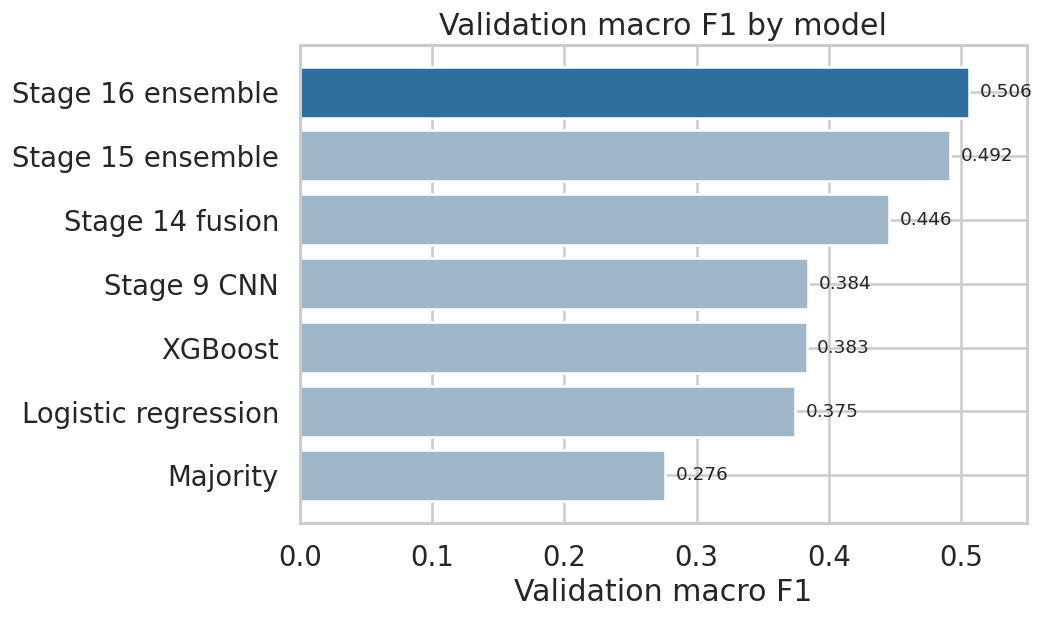

In [9]:
metrics = load_stage13_table("model_validation_metrics")
selected_metrics = selected_model_frame(metrics)

if selected_metrics.empty:
    print("Model validation metrics are unavailable; run the analysis cell first.")
else:
    plot_frame = selected_metrics.sort_values("macro_f1")
    colors = [
        "#2f6f9f" if name == STAGE16_MODEL_NAME else "#9fb7c9"
        for name in plot_frame["model_name"]
    ]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(plot_frame["model_label"], plot_frame["macro_f1"], color=colors)
    ax.set_xlabel("Validation macro F1")
    ax.set_ylabel("")
    ax.set_xlim(0, max(0.55, float(plot_frame["macro_f1"].max()) + 0.04))
    ax.set_title("Validation macro F1 by model")
    for value, label in zip(plot_frame["macro_f1"], plot_frame["model_label"]):
        ax.text(value + 0.008, label, f"{value:.3f}", va="center", fontsize=11)
    fig.tight_layout()
    save_presentation_figure(fig, "model_macro_f1_summary.png")
    plt.show()

### Class-Level Behavior

This figure shows Wake, Non-REM, and REM F1 for the selected comparison models. The artifact is `presentation_figures/selected_model_class_f1.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/selected_model_class_f1.png


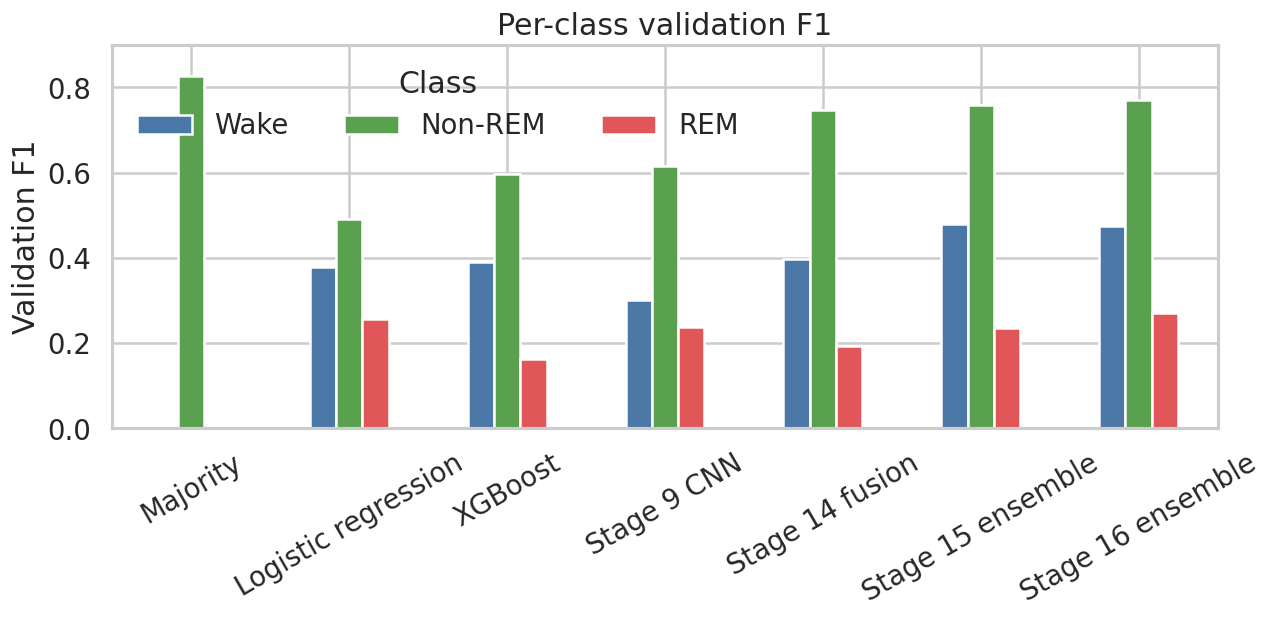

In [10]:
if selected_metrics.empty:
    print("Model validation metrics are unavailable; run the analysis cell first.")
else:
    class_f1 = selected_metrics[
        ["model_label", "Wake_f1", "Non_REM_f1", "REM_f1"]
    ].rename(
        columns={"Wake_f1": "Wake", "Non_REM_f1": "Non-REM", "REM_f1": "REM"}
    )
    class_f1 = class_f1.set_index("model_label")[CLASS_LABELS]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    class_f1.plot(kind="bar", ax=ax, color=["#4c78a8", "#59a14f", "#e15759"])
    ax.set_xlabel("")
    ax.set_ylabel("Validation F1")
    ax.set_ylim(0, 0.9)
    ax.set_title("Per-class validation F1")
    ax.legend(title="Class", frameon=False, ncol=3)
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    save_presentation_figure(fig, "selected_model_class_f1.png")
    plt.show()

### Stage 16 Confusion Patterns

This figure normalizes the Stage 16 ensemble confusion matrix by true class, so each row shows the percentage of that true class assigned to each predicted class. The artifact is `presentation_figures/stage16_normalized_confusion_matrix.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/stage16_normalized_confusion_matrix.png


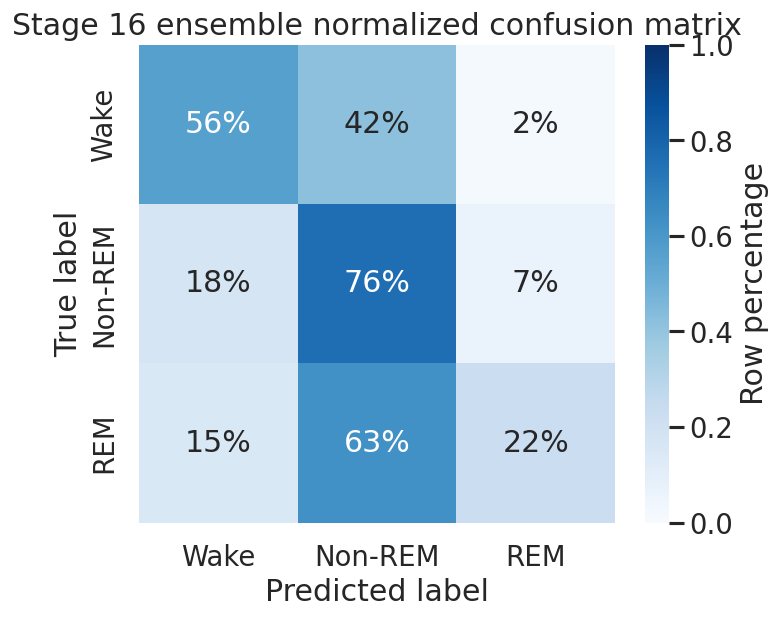

pred_label,Wake,Non-REM,REM
true_label,,,
Wake,1190,883,37
Non-REM,1492,6447,557
REM,212,892,317


In [11]:
combined_predictions = load_stage13_table("combined_validation_predictions")
stage16_predictions = combined_predictions[
    combined_predictions.get("model_name", pd.Series(dtype="object")) == STAGE16_MODEL_NAME
].copy()

if stage16_predictions.empty:
    print("Stage 16 ensemble predictions are unavailable; run the analysis cell first.")
else:
    counts = pd.crosstab(
        stage16_predictions["true_label"],
        stage16_predictions["pred_label"],
    ).reindex(index=CLASS_LABELS, columns=CLASS_LABELS, fill_value=0)
    normalized = counts.div(counts.sum(axis=1), axis=0)
    annotations = normalized.apply(lambda column: column.map(lambda value: f"{value:.0%}"))

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(
        normalized,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Row percentage"},
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Stage 16 ensemble normalized confusion matrix")
    fig.tight_layout()
    save_presentation_figure(fig, "stage16_normalized_confusion_matrix.png")
    plt.show()
    display(counts)

### Transition-Neighborhood Effects

This figure compares Stage 16 ensemble performance away from transitions versus within the configured transition neighborhood. The artifact is `presentation_figures/stage16_transition_effects.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/stage16_transition_effects.png


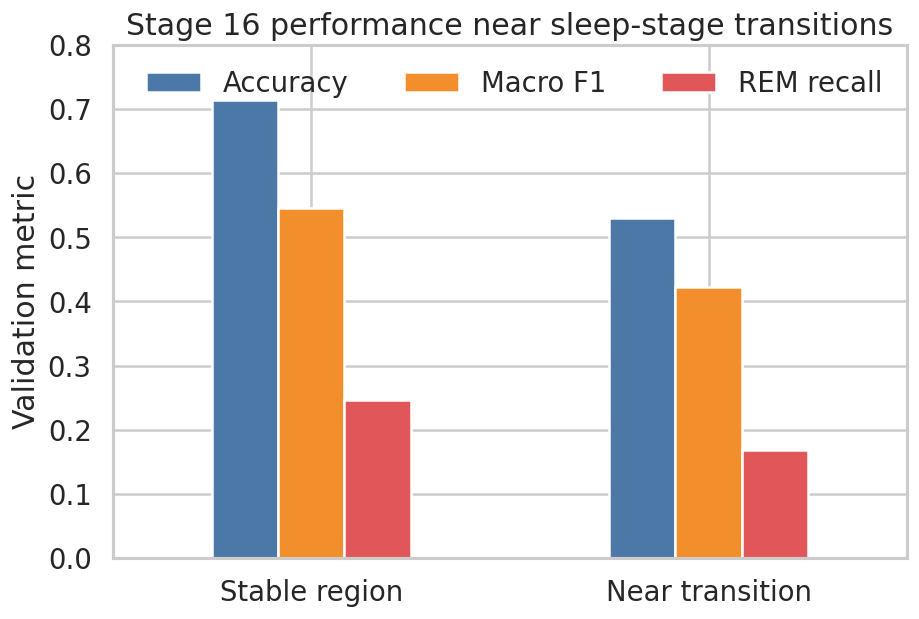

In [12]:
temporal = load_stage13_table("temporal_error_summary")
stage16_temporal = temporal[temporal.get("model_name", pd.Series(dtype="object")) == STAGE16_MODEL_NAME].copy()

if stage16_temporal.empty:
    print("Stage 16 temporal summary is unavailable; run the analysis cell first.")
else:
    stage16_temporal["region"] = np.where(
        stage16_temporal["near_transition"].astype(str).str.lower() == "true",
        "Near transition",
        "Stable region",
    )
    transition_plot = stage16_temporal.set_index("region")[
        ["accuracy", "macro_f1", "REM_recall"]
    ].rename(columns={"accuracy": "Accuracy", "macro_f1": "Macro F1", "REM_recall": "REM recall"})
    transition_plot = transition_plot.reindex(["Stable region", "Near transition"])

    fig, ax = plt.subplots(figsize=(8, 5.5))
    transition_plot.plot(kind="bar", ax=ax, color=["#4c78a8", "#f28e2b", "#e15759"])
    ax.set_xlabel("")
    ax.set_ylabel("Validation metric")
    ax.set_ylim(0, 0.8)
    ax.set_title("Stage 16 performance near sleep-stage transitions")
    ax.legend(frameon=False, ncol=3)
    ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    save_presentation_figure(fig, "stage16_transition_effects.png")
    plt.show()

### Participant-Level Variability

This figure shows Stage 16 ensemble macro F1 for each validation participant. The artifact is `presentation_figures/stage16_participant_macro_f1.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/stage16_participant_macro_f1.png


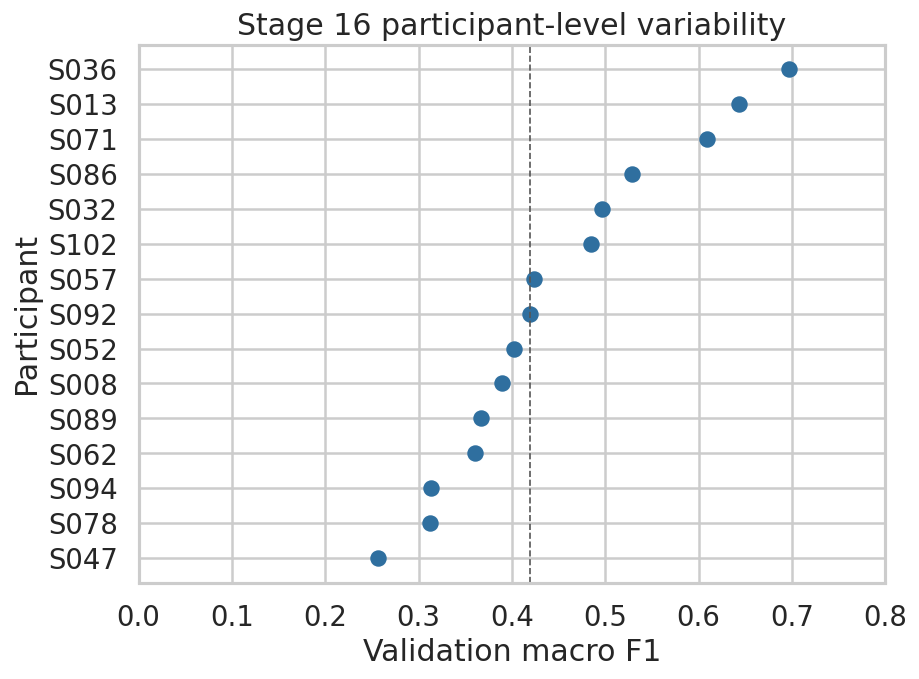

In [13]:
participant_summary = load_stage13_table("participant_error_summary")
stage16_participants = participant_summary[
    participant_summary.get("model_name", pd.Series(dtype="object")) == STAGE16_MODEL_NAME
].copy()

if stage16_participants.empty:
    print("Stage 16 participant summary is unavailable; run the analysis cell first.")
else:
    stage16_participants = stage16_participants.sort_values("macro_f1")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        stage16_participants["macro_f1"],
        stage16_participants["participant_id"],
        s=70,
        color="#2f6f9f",
    )
    ax.axvline(stage16_participants["macro_f1"].median(), color="#555555", linestyle="--", linewidth=1)
    ax.set_xlabel("Validation macro F1")
    ax.set_ylabel("Participant")
    ax.set_xlim(0, 0.8)
    ax.set_title("Stage 16 participant-level variability")
    fig.tight_layout()
    save_presentation_figure(fig, "stage16_participant_macro_f1.png")
    plt.show()

### Confidence Diagnostics

This figure compares Stage 16 ensemble confidence-bin accuracy against mean confidence. The artifact is `presentation_figures/stage16_confidence_bins.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/stage16_confidence_bins.png


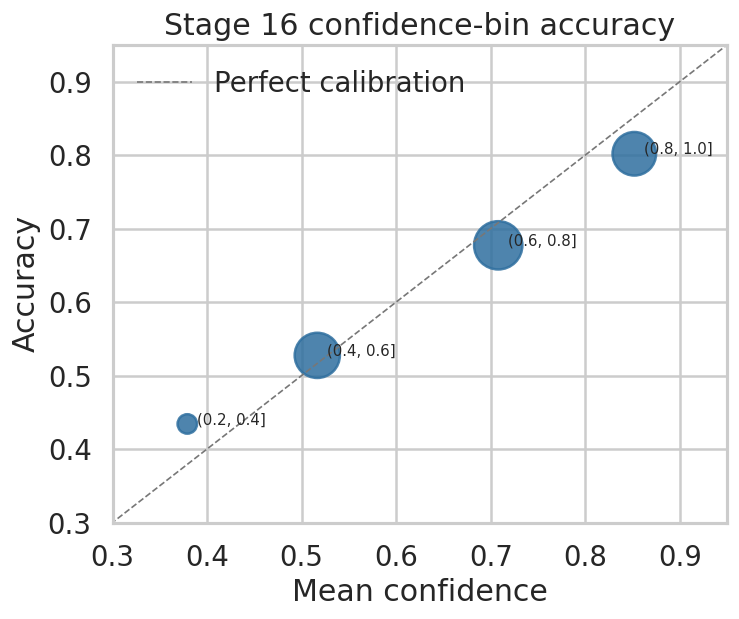

In [14]:
confidence_bins = load_stage13_table("confidence_bins")
stage16_bins = confidence_bins[
    confidence_bins.get("model_name", pd.Series(dtype="object")) == STAGE16_MODEL_NAME
].copy()

if stage16_bins.empty:
    print("Stage 16 confidence bins are unavailable; run the analysis cell first.")
else:
    for column in ["n_predictions", "accuracy", "mean_confidence"]:
        stage16_bins[column] = pd.to_numeric(stage16_bins[column], errors="coerce")
    stage16_bins = stage16_bins.dropna(subset=["n_predictions", "accuracy", "mean_confidence"])
    stage16_bins = stage16_bins[stage16_bins["n_predictions"] > 0]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1, label="Perfect calibration")
    ax.scatter(
        stage16_bins["mean_confidence"],
        stage16_bins["accuracy"],
        s=np.sqrt(stage16_bins["n_predictions"]) * 12,
        color="#2f6f9f",
        alpha=0.85,
    )
    for _, row in stage16_bins.iterrows():
        ax.text(row["mean_confidence"] + 0.01, row["accuracy"], str(row["confidence_bin"]), fontsize=9)
    ax.set_xlabel("Mean confidence")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0.3, 0.95)
    ax.set_ylim(0.3, 0.95)
    ax.set_title("Stage 16 confidence-bin accuracy")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_presentation_figure(fig, "stage16_confidence_bins.png")
    plt.show()

### High-Confidence Error Types

This figure summarizes the most common Stage 16 ensemble errors among predictions above the configured high-confidence threshold. The artifact is `presentation_figures/stage16_high_confidence_error_types.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/stage16_high_confidence_error_types.png


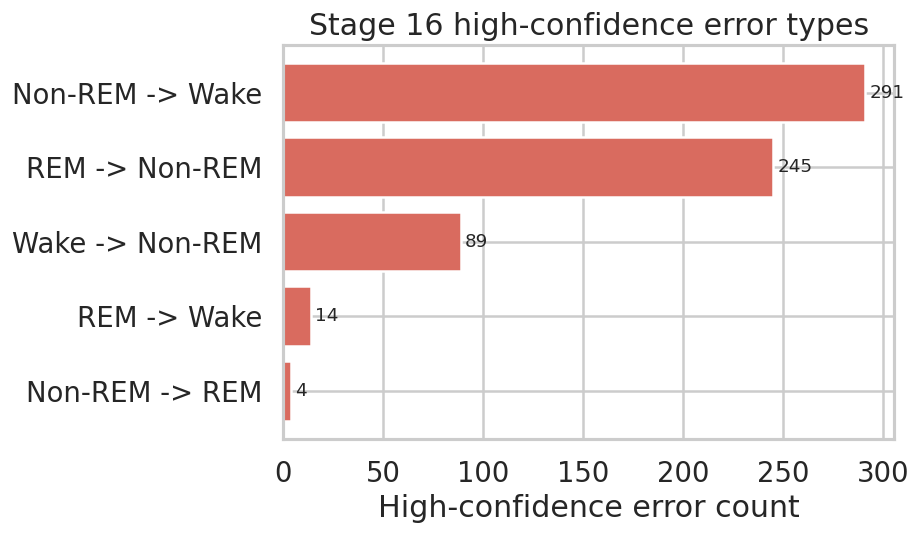

In [15]:
high_confidence_errors = load_stage13_table("high_confidence_errors")
stage16_high_confidence = high_confidence_errors[
    high_confidence_errors.get("model_name", pd.Series(dtype="object")) == STAGE16_MODEL_NAME
].copy()

if stage16_high_confidence.empty:
    print("No Stage 16 high-confidence errors are available at the configured threshold.")
else:
    error_counts = stage16_high_confidence["error_type"].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.barh(error_counts.index, error_counts.values, color="#d96b5f")
    ax.set_xlabel("High-confidence error count")
    ax.set_ylabel("")
    ax.set_title("Stage 16 high-confidence error types")
    for count, label in zip(error_counts.values, error_counts.index):
        ax.text(count + 2, label, f"{count:,}", va="center", fontsize=11)
    fig.tight_layout()
    save_presentation_figure(fig, "stage16_high_confidence_error_types.png")
    plt.show()

### Validation Summary Panel

This four-panel figure combines the model-level comparison, Stage 16 per-class F1, transition-neighborhood effect, and participant-level variability. The artifact is `presentation_figures/validation_summary_panel.png`.

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage13_error_analysis/presentation_figures/validation_summary_panel.png


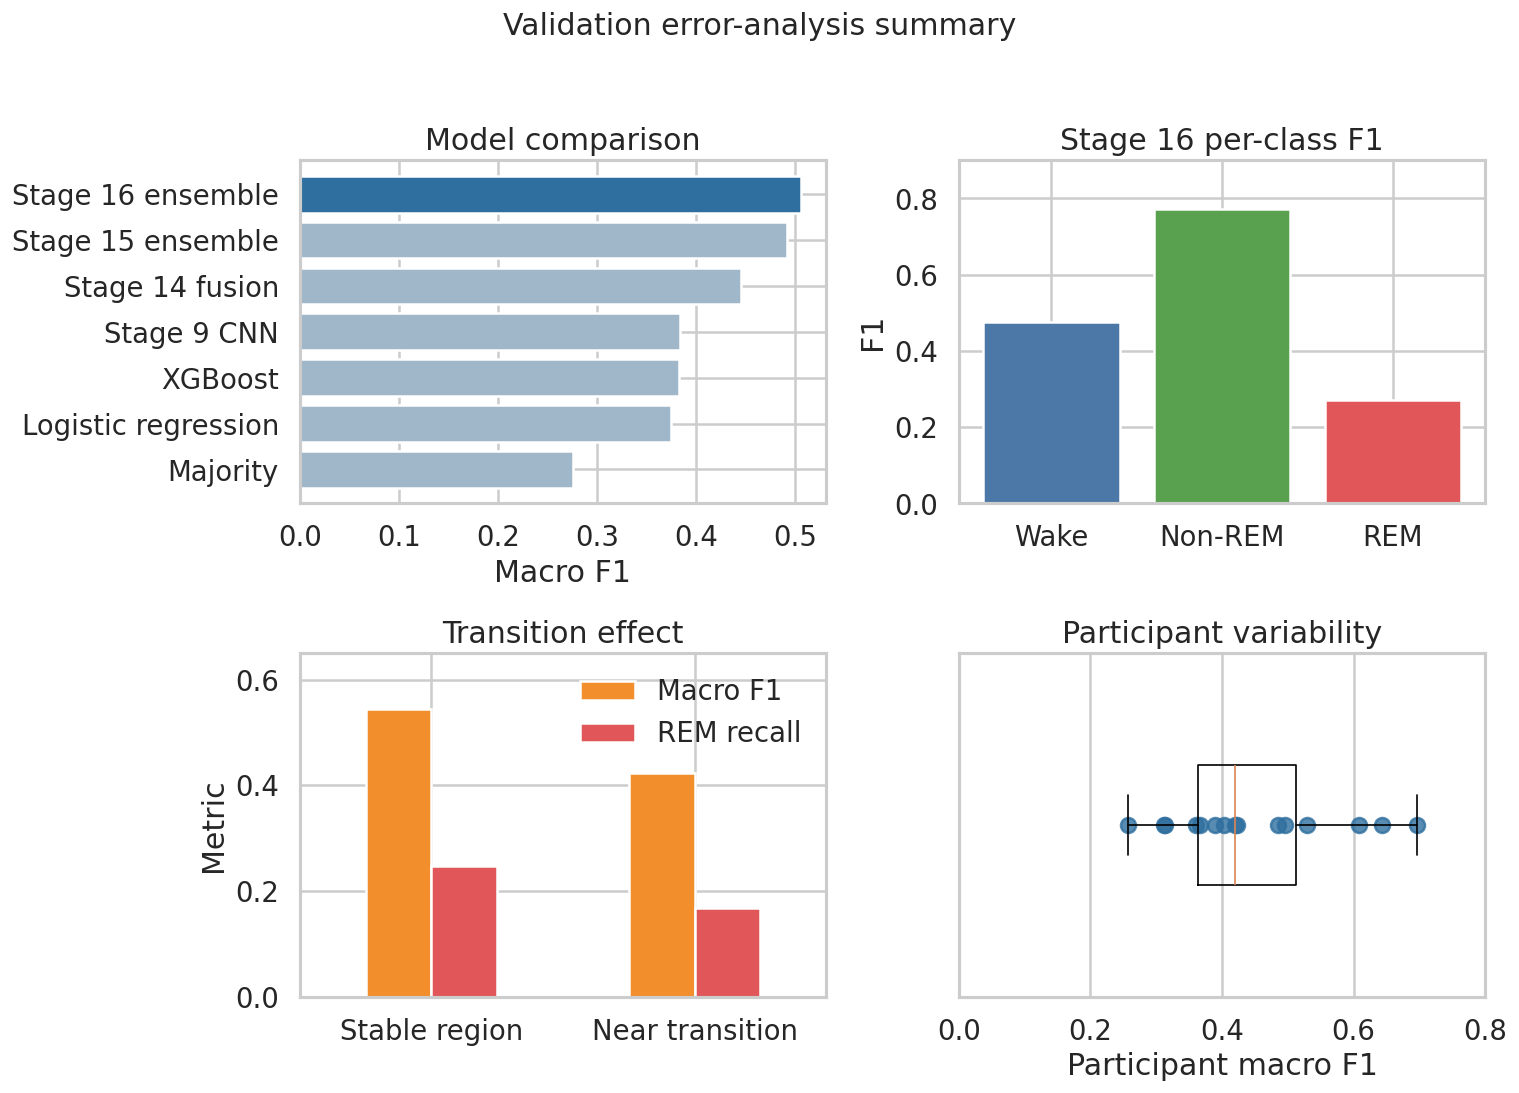

In [16]:
required_tables_available = (
    not selected_metrics.empty
    and not stage16_participants.empty
    and not stage16_temporal.empty
)

if not required_tables_available:
    print("Summary panel inputs are unavailable; run the preceding analysis and figure cells first.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    ax = axes[0, 0]
    compact_models = selected_metrics.sort_values("macro_f1")
    colors = [
        "#2f6f9f" if name == STAGE16_MODEL_NAME else "#9fb7c9"
        for name in compact_models["model_name"]
    ]
    ax.barh(compact_models["model_label"], compact_models["macro_f1"], color=colors)
    ax.set_xlabel("Macro F1")
    ax.set_title("Model comparison")

    ax = axes[0, 1]
    stage16_row = selected_metrics[selected_metrics["model_name"] == STAGE16_MODEL_NAME].iloc[0]
    class_values = [stage16_row["Wake_f1"], stage16_row["Non_REM_f1"], stage16_row["REM_f1"]]
    ax.bar(CLASS_LABELS, class_values, color=["#4c78a8", "#59a14f", "#e15759"])
    ax.set_ylim(0, 0.9)
    ax.set_ylabel("F1")
    ax.set_title("Stage 16 per-class F1")

    ax = axes[1, 0]
    transition_plot[["Macro F1", "REM recall"]].plot(kind="bar", ax=ax, color=["#f28e2b", "#e15759"])
    ax.set_ylim(0, 0.65)
    ax.set_xlabel("")
    ax.set_ylabel("Metric")
    ax.set_title("Transition effect")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(frameon=False)

    ax = axes[1, 1]
    ax.boxplot(stage16_participants["macro_f1"], vert=False, widths=0.35)
    ax.scatter(stage16_participants["macro_f1"], np.ones(len(stage16_participants)), alpha=0.8, color="#2f6f9f")
    ax.set_yticks([])
    ax.set_xlim(0, 0.8)
    ax.set_xlabel("Participant macro F1")
    ax.set_title("Participant variability")

    fig.suptitle("Validation error-analysis summary", y=1.02, fontsize=18)
    fig.tight_layout()
    save_presentation_figure(fig, "validation_summary_panel.png")
    plt.show()

## Interpretation Checklist

Use the saved tables and figures to answer: which classes dominate errors; whether errors are concentrated in a few participants; whether context/sequence models reduce transition-adjacent errors; whether tabular and neural models make complementary mistakes; and whether the next backup should prioritize enhanced features, temporal smoothing, calibration, ensembling, or preprocessing changes.